# ML: Non-Linear Regression — Polynomial / Cubic

A cubic (degree-3 polynomial) handles relationships with two inflection points — the classic S-curve.

## Theory
- https://mlu-explain.github.io/linear-regression/
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

## Equation
`y = a · x³ + b · x² + c · x + d`

`PolynomialFeatures(degree=3)` adds `x²` and `x³` columns; `LinearRegression` solves for the four coefficients.

## Problem Statement — Neighborhood Quality Index vs price

NQI is a composite score (0–100) combining schools, safety, walkability and amenities.

- Below ~30 — rough zones, prices stay low and flat.
- 30–60 — stable working-class neighborhoods, slow rise.
- 60–85 — middle / upper-middle suburbs, steep premium.
- 85–100 — luxury enclaves, surge.

That shape — flat → rise → steep → flat (in growth rate) — is what a cubic captures.

| nqi | price ($k) |
| :-: | :--------: |
| 10  | 180  |
| 20  | 195  |
| 30  | 215  |
| 40  | 250  |
| 50  | 310  |
| 60  | 410  |
| 70  | 560  |
| 80  | 760  |
| 85  | 900  |
| 90  | 1080 |
| 95  | 1320 |
| 100 | 1600 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

%matplotlib inline

In [2]:
data = {
    'nqi':   [10, 20, 30, 40, 50, 60, 70, 80, 85, 90, 95, 100],
    'price': [180, 195, 215, 250, 310, 410, 560, 760, 900, 1080, 1320, 1600],
}
test = {'nqi': [25, 55, 75, 92]}

df = pd.DataFrame(data)
df

,nqi,price
0,10,180
1,20,195
2,30,215
3,40,250
4,50,310
5,60,410
6,70,560
7,80,760
8,85,900
9,90,1080


Text(0.5, 1.0, 'S-curve: flat low end, steep middle, luxury surge')

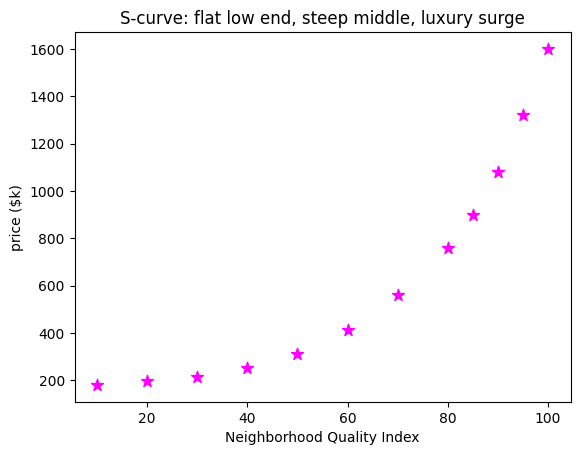

In [3]:
plt.scatter(df.nqi, df.price, color='magenta', marker='*', s=80)
plt.xlabel('Neighborhood Quality Index')
plt.ylabel('price ($k)')
plt.title('S-curve: flat low end, steep middle, luxury surge')

In [4]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(df[['nqi']].values)
reg = LinearRegression().fit(X, df['price'])

# PolynomialFeatures returns columns in order [x, x^2, x^3]
c1, c2, c3 = reg.coef_
d = reg.intercept_
print(f'fit: price = {c3:.4f} * nqi^3 + {c2:.4f} * nqi^2 + {c1:.4f} * nqi + {d:.4f}')

fit: price = 0.0035 * nqi^3 + -0.3152 * nqi^2 + 11.4541 * nqi + 78.0122


In [5]:
tst = pd.DataFrame(test)
tst['price'] = reg.predict(poly.transform(tst[['nqi']].values))
tst

,nqi,price
0,25,222.066871
1,55,336.907452
2,75,640.812276
3,92,1189.637777


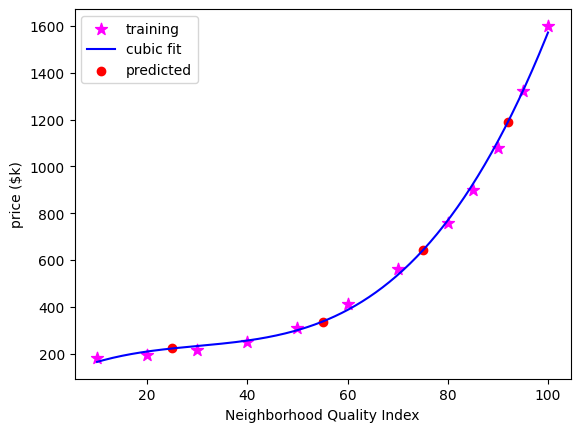

In [6]:
nqi_grid = np.linspace(df.nqi.min(), df.nqi.max(), 200)
curve = reg.predict(poly.transform(nqi_grid.reshape(-1, 1)))

plt.scatter(df.nqi, df.price, color='magenta', marker='*', s=80, label='training')
plt.plot(nqi_grid, curve, color='blue', label='cubic fit')
plt.scatter(tst.nqi, tst.price, color='red', label='predicted')
plt.xlabel('Neighborhood Quality Index')
plt.ylabel('price ($k)')
plt.legend()